In [2]:
from pathlib import Path
# import required packages:
import skysurvey
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


import lightcurve
import lsst_functions
from lightcurve import generate_snia_lightcurve, plot_lightcurve, limit_mag_dict, get_valid_bands
from lightcurve import generate_snia_dict, generate_ordered_parameter_list, determine_visibility

# import cosmology parameters
import sncosmo
from params import p_cosmology

lsst_colors = ["tab:purple", "tab:green", "tab:orange", "tab:red", "tab:brown", "0.5"]
lsst_bands = ["lsstu", "lsstg", "lsstr", "lssti", "lsstz", "lssty"]
snia_lightcurve_params = ["z", "x1", "c", "t0", "magabs", "ra", "dec"] #note: lightcurve.py uses "redshift" 

/home/denzelgoh/micromamba/envs/TransietnLightcurves/lib/python3.14/site-packages/ligo/skymap/bayestar/__init__.py:34: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


In [8]:
data =  np.load("results_5/aggregated_results.npz") # main data from 91 million SNIa dataset at 0.01 z bins

In [9]:
data.files

['z_edges',
 'z_mid',
 'n_sources_all',
 'n_sources_detected',
 'total_rows',
 'total_detected',
 'n_lsstu',
 'n_lsstg',
 'n_lsstr',
 'n_lssti',
 'n_lsstz',
 'n_lssty']

In [3]:
from astropy import units as u
from params import p_cosmology

import astropy.cosmology as acosmo
cosmo = acosmo.LambdaCDM(H0=p_cosmology['h0']* u.km / u.s / u.Mpc, 
                         Om0=p_cosmology['omega_M'],
                        Ode0=p_cosmology['omega_L'])
shell_volumes = np.diff(cosmo.comoving_volume(np.arange(0, 1.01, 0.01))).to(u.Mpc**3)

In [4]:
shell_volumes

<Quantity [3.66001963e+05, 2.54114463e+06, 6.83412721e+06, 1.31826463e+07,
           2.15246821e+07, 3.17985555e+07, 4.39429837e+07, 5.78971324e+07,
           7.36006670e+07, 9.09938004e+07, 1.10017339e+08, 1.30612728e+08,
           1.52722088e+08, 1.76288258e+08, 2.01254831e+08, 2.27566187e+08,
           2.55167521e+08, 2.84004881e+08, 3.14025185e+08, 3.45176251e+08,
           3.77406817e+08, 4.10666564e+08, 4.44906127e+08, 4.80077120e+08,
           5.16132139e+08, 5.53024783e+08, 5.90709657e+08, 6.29142384e+08,
           6.68279607e+08, 7.08078996e+08, 7.48499251e+08, 7.89500100e+08,
           8.31042300e+08, 8.73087636e+08, 9.15598915e+08, 9.58539966e+08,
           1.00187563e+09, 1.04557175e+09, 1.08959517e+09, 1.13391373e+09,
           1.17849623e+09, 1.22331246e+09, 1.26833315e+09, 1.31352999e+09,
           1.35887557e+09, 1.40434344e+09, 1.44990802e+09, 1.49554463e+09,
           1.54122946e+09, 1.58693956e+09, 1.63265281e+09, 1.67834794e+09,
           1.72400445e+09

In [5]:
redshift_data = np.load("results_5/aggregated_redshifts.npz")
print(redshift_data.files)

z_all =  redshift_data["z_all"]
z_detected = redshift_data["z_detected"]

print(len(z_all))
print(len(z_detected))

['z_all', 'z_detected', 'total_rows', 'total_detected']
91139849
5127478


In [10]:
z_edges = data["z_edges"]
z_mid = data["z_mid"]

n_sources_all = data["n_sources_all"]
n_sources_detected = data["n_sources_detected"]

total_rows = data["total_rows"]
total_detected = data["total_detected"]

n_lsstu = data["n_lsstu"]
n_lsstg = data["n_lsstg"]
n_lsstr = data["n_lsstr"]
n_lssti = data["n_lssti"]
n_lsstz = data["n_lsstz"]
n_lssty = data["n_lssty"]

In [11]:
T_window = (3750/365) #in yr, since our volumetric rates are in yr. Petrecca & Botticella et al.
Rz_bin_counts = n_sources_detected / shell_volumes / T_window #Mpc^-3 yr^-1
Rz_bin_counts_all = n_sources_all / shell_volumes / T_window #Mpc^-3 yr^-1
Rz_bin_counts[5:7], Rz_bin_counts_all[5:7]

(<Quantity [7.75335008e-06, 7.97618422e-06] 1 / Mpc3>,
 <Quantity [2.56475801e-05, 2.59087550e-05] 1 / Mpc3>)

In [12]:
print(total_rows, total_detected)

91139849 5127478


In [13]:
n_sources_detected

array([    18,    176,    481,   1002,   1647,   2533,   3601,   4706,
         6052,   7558,   9209,  11143,  13324,  15394,  17758,  20889,
        23331,  26219,  29278,  33003,  36422,  39493,  43197,  46193,
        49803,  53225,  57030,  60190,  64067,  67478,  70787,  74144,
        77190,  80505,  83366,  86846,  89227,  92783,  94858,  97302,
        99981, 101789, 102797, 103993, 105964, 106848, 107833, 107840,
       108961, 109518, 110011, 110076, 110379, 109395, 107908, 106959,
       105253, 102713,  99013,  96726,  93907,  91201,  87907,  84466,
        81840,  77905,  74419,  72028,  68576,  65149,  61960,  58166,
        54530,  50520,  46108,  41415,  37855,  33710,  30180,  26865,
        23775,  21082,  18751,  16528,  15126,  13181,  11917,  10386,
         9175,   8050,   7080,   5983,   5091,   4057,   3505,   2877,
         2270,   1887,   1442,   1223])

In [14]:
n_sources_all

array([     82,     615,    1593,    3365,    5434,    8379,   11697,
         15567,   20007,   25165,   30607,   36921,   44155,   50940,
         59430,   68803,   77411,   87817,   98221,  109089,  121418,
        133585,  147403,  161136,  175380,  190281,  205593,  222213,
        239396,  256904,  274970,  293029,  312990,  332773,  353085,
        374239,  396714,  420004,  440987,  463807,  487851,  512810,
        537416,  562863,  588896,  613949,  641372,  669833,  697666,
        725256,  753213,  784499,  812583,  842412,  873400,  902746,
        934667,  965957,  997678, 1030341, 1063609, 1095894, 1127244,
       1163364, 1197007, 1227276, 1263503, 1300284, 1332321, 1367837,
       1402522, 1437009, 1476274, 1509857, 1546267, 1581712, 1617597,
       1654382, 1692206, 1726520, 1763631, 1798508, 1836024, 1869519,
       1909777, 1945088, 1980039, 2017466, 2053833, 2092420, 2127621,
       2161742, 2198865, 2234992, 2270707, 2308703, 2342851, 2378936,
       2411171, 2448

In [15]:
z_mid = (z_edges[:-1] + z_edges[1:]) / 2
from transient_rates import R_SFR
# intervals = n_sources.index
# z_edges = .np.array([intervals[0].left] + [interval.right for interval in intervals])
R_z = R_SFR(z_mid , R0=p_cosmology['R0']['SN Ia'].to(u.Mpc**-3 / u.yr))

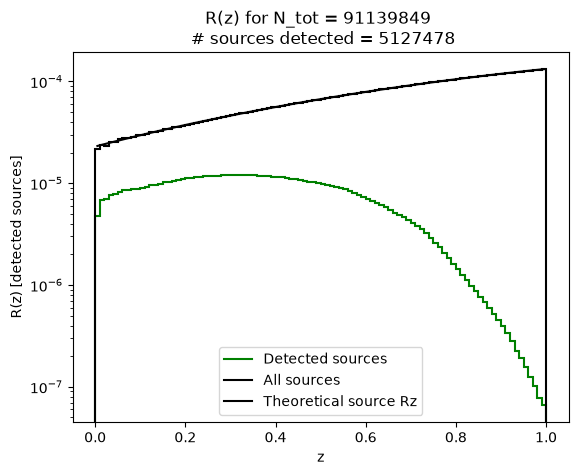

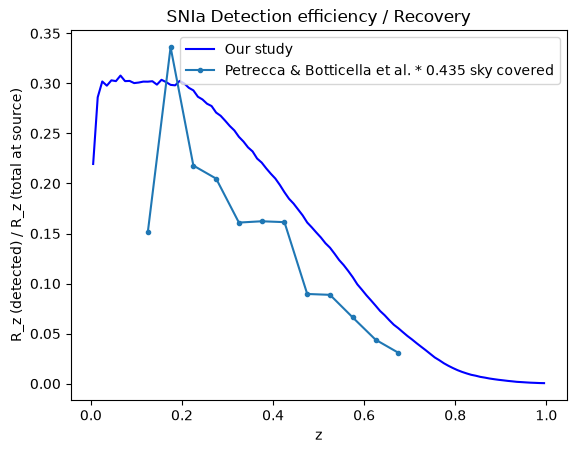

In [39]:
# plt.plot(z_mid , Rz_bin_counts, '.')
# plt.plot(z_mid, Rz_bin_counts_all, '.')
plt.stairs(Rz_bin_counts * (1 + z_mid), z_edges, label='Detected sources', color='green', lw = 1.5)
plt.stairs(Rz_bin_counts_all * (1 + z_mid), z_edges, label='All sources', color='k', lw = 1.5)
plt.plot(z_mid, R_z, label='Theoretical source Rz', color='k', lw = 1.5)
plt.xlabel('z')
plt.yscale('log')
plt.ylabel('R(z) [detected sources]')
plt.legend()

plt.title(f'R(z) for N_tot = {total_rows} \n # sources detected = {total_detected}')
plt.show()

plt.plot(z_mid, Rz_bin_counts / Rz_bin_counts_all, color = 'b', label = 'Our study')
plt.plot(z_mid_pet, eff_pet * 0.435, '.-', label = 'Petrecca & Botticella et al. * 0.435 sky covered')
plt.title('SNIa Detection efficiency / Recovery')
plt.xlabel('z')
plt.ylabel('R_z (detected) / R_z (total at source)')
plt.legend()

In [21]:
# Petrecca et al 2014 (note: they used 15 sq deg only)
z_mid_pet = np.array([
    0.125, 0.175, 0.225, 0.275,
    0.325, 0.375, 0.425, 0.475,
    0.525, 0.575, 0.625, 0.675
])

eff_pet = np.array([
    34.8, 77.3, 50.1, 47.1,
    37.0, 37.3, 37.1, 20.6,
    20.4, 15.2, 10.1, 7.1
]) / 100

Text(0.5, 1.0, 'Ratio of rates =  rate * (1+z)/ R_z (theory) \n for N_tot = 91139849, # sources detected = 5127478')

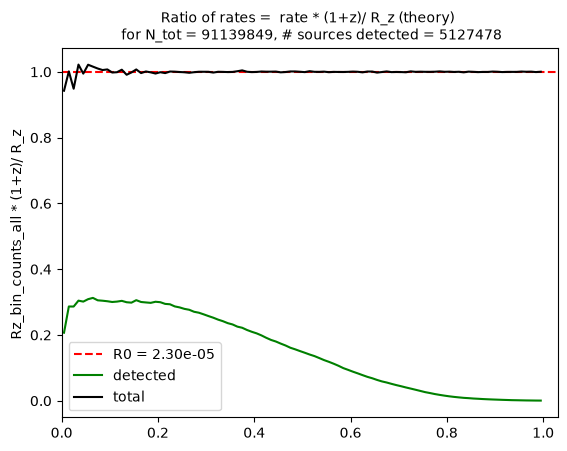

In [23]:
plt.axhline(1, color='r', linestyle='--', label='R0 = {:.2e}'.format(p_cosmology['R0']['SN Ia'].to(u.Mpc**-3 / u.yr).value))
plt.plot(z_mid, Rz_bin_counts * (1+z_mid)/ R_z , color='g', linestyle = '-', label='detected')
plt.plot(z_mid, Rz_bin_counts_all * (1+z_mid)/ R_z , color='k', linestyle = '-', label='total')


plt.ylabel('Rz_bin_counts_all * (1+z)/ R_z ')

plt.xlim(0, 1.03)
plt.legend()
plt.title(f'Ratio of rates =  rate * (1+z)/ R_z (theory) \n for N_tot = {total_rows}, # sources detected = {total_detected}', fontsize = 10)

In [18]:
Rz_bin_counts * (1+z_mid)/ R_z 

<Quantity [0.20691333, 0.28657483, 0.2864487 , 0.30433607, 0.30145383,
           0.30884341, 0.31272351, 0.30535631, 0.30414583, 0.30253735,
           0.30027557, 0.30146341, 0.30371319, 0.29952603, 0.29825767,
           0.30581033, 0.30026773, 0.29888823, 0.29762662, 0.30098269,
           0.29962241, 0.29450906, 0.29332997, 0.28681035, 0.28381618,
           0.27937038, 0.27660408, 0.27056859, 0.26767206, 0.26271441,
           0.25745019, 0.25248366, 0.24664706, 0.24186966, 0.23595422,
           0.2319852 , 0.22533484, 0.22188798, 0.21515387, 0.20962871,
           0.20488683, 0.19867848, 0.19135667, 0.18484853, 0.18006607,
           0.17377744, 0.1680367 , 0.16118002, 0.15635701, 0.1510311 ,
           0.14593379, 0.14058566, 0.13584371, 0.12984295, 0.1236213 ,
           0.11836276, 0.1125949 , 0.10629532, 0.09919587, 0.09387631,
           0.08835112, 0.08323316, 0.0778711 , 0.07267022, 0.06842586,
           0.06333612, 0.0588635 , 0.05545977, 0.05142752, 0.04761067,
      

In [19]:
n_alerts_total = (data["n_lsstu"]+ data["n_lsstg"]+ data["n_lsstr"]+ data["n_lssti"]+ data["n_lsstz"]+ data["n_lssty"])
alerts_per_night = n_alerts_total / 3650
detected_sources_per_night = 5127478 / 3650
total_sources_per_night = 91139849 / 3650

In [20]:
18000 / 41253

0.4363319031343175

In [68]:
print(f'SNIa detected per night, {detected_sources_per_night:.2f} out of {total_sources_per_night:.2f}')
print(f'SNIa alerts per night {alerts_per_night:.2f}')

SNIa detected per night, 1404.79 out of 24969.82
SNIa alerts per night 19891.52


In [ ]:
plt.plot(zn_sources_detected / n_sources_all

array([0.2195122 , 0.28617886, 0.30194601, 0.29777117, 0.30309165,
       0.30230338, 0.30785672, 0.30230616, 0.30249413, 0.30033777,
       0.30087888, 0.30180656, 0.30175518, 0.30219867, 0.29880532,
       0.30360595, 0.30139128, 0.29856406, 0.29808289, 0.30253279,
       0.299972  , 0.29563948, 0.29305374, 0.28667089, 0.28397195,
       0.27971789, 0.27739271, 0.27086624, 0.26761934, 0.26265842,
       0.25743536, 0.25302615, 0.2466213 , 0.24192167, 0.23610745,
       0.23206026, 0.22491518, 0.2209098 , 0.21510385, 0.20978985,
       0.20494167, 0.19849262, 0.19128013, 0.18475721, 0.1799367 ,
       0.174034  , 0.16812864, 0.16099535, 0.15617932, 0.15100599,
       0.14605563, 0.14031375, 0.1358372 , 0.12985926, 0.12354935,
       0.11848183, 0.11261016, 0.10633289, 0.09924344, 0.09387766,
       0.0882909 , 0.08322064, 0.077984  , 0.07260496, 0.06837053,
       0.06347798, 0.05889895, 0.05539405, 0.05147108, 0.04762921,
       0.04417756, 0.04047713, 0.03693759, 0.03346012, 0.02981